In [1]:
import torch
import torch.nn as nn
device = torch.device("cuda" if torch.cuda.is_available else "cpu")
image = torch.rand(3, 28, 28)
image.shape

torch.Size([3, 28, 28])

In [2]:
image = image.unsqueeze(0)
image.shape

torch.Size([1, 3, 28, 28])

In [3]:
from torchvision import datasets
from torchvision.transforms import ToTensor

train_data = datasets.CIFAR10(
    root = 'data', 
    train = True, 
    transform= ToTensor(),
    download= False
)
test_data = datasets.CIFAR10(
    root = 'data', 
    train = False, 
    transform = ToTensor(), 
    download= False
)

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2+cu118
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [14]:
v , _= train_data[0]
v.shape

torch.Size([3, 32, 32])

In [4]:
x, t = train_data[0]
filter = nn.Conv2d(3, 16, 3)
output = filter(x)
print(output.shape)

torch.Size([16, 30, 30])


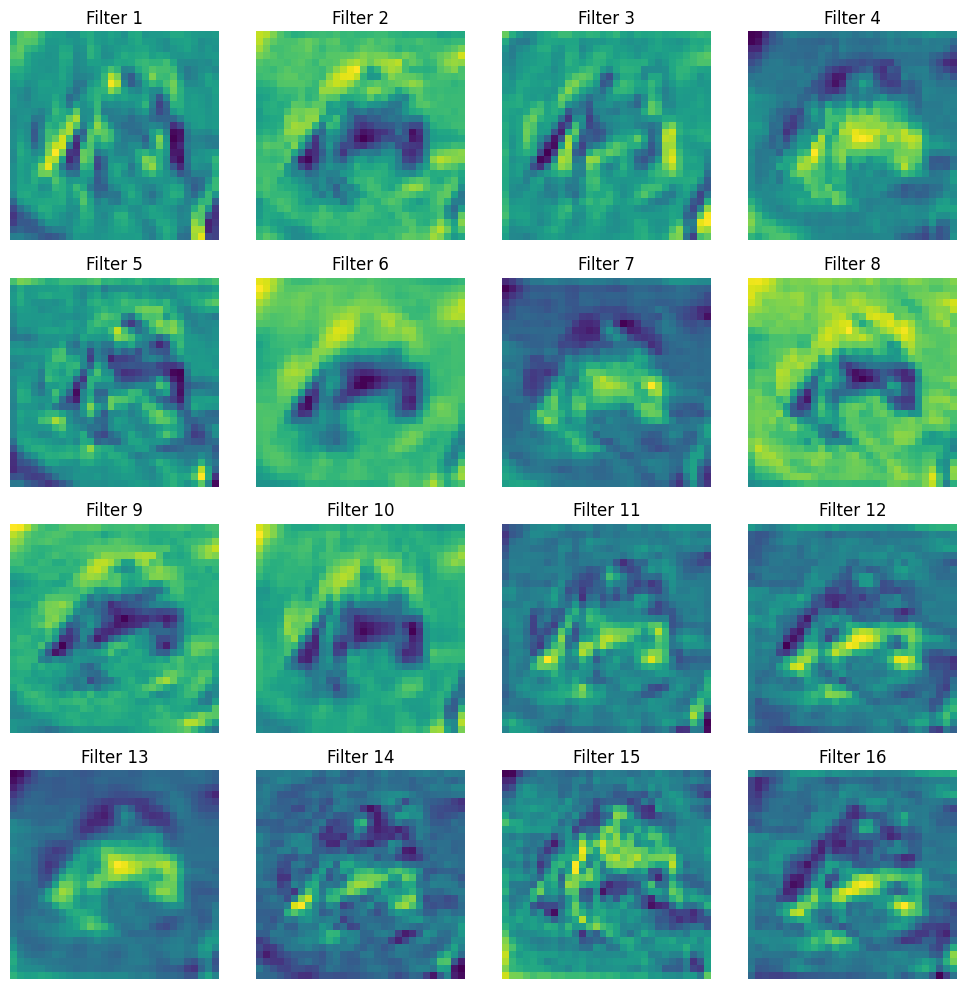

In [5]:
import matplotlib.pyplot as plt 
fig , axes= plt.subplots(4, 4, figsize = (10 , 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(output[i].detach().cpu())
    ax.set_title(f"Filter {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3)
        self.Relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.fc = nn.Linear(2304, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.Relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.Relu(x)
        x = self.pool(x)
        x = torch.flatten(x, start_dim = 1)
        x = self.fc(x)
        x = self.fc2(x)
        return x

model = CNN().to(device)

In [17]:
train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size = 128,
    shuffle = True
)

In [8]:
next(iter(train_loader))[0].shape


torch.Size([128, 3, 32, 32])

In [18]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(
    model.parameters(), 
    lr=0.01
)


In [10]:
print(len(train_loader))

391


In [19]:
from tqdm import tqdm
epochs = 30

for epoch in range(epochs):
    correct = 0
    total = 0
    for X,  target in tqdm(train_loader , desc = f"EPOCH { epoch + 1}"):
        X = X.to(device)
        target = target.to(device)
        output= model(X)
        loss = loss_function(output, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        predicted = torch.argmax(output, dim=1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

    accuracy = (correct/total) * 100
    print("Accuracy : ", round(accuracy, 2))

EPOCH 1: 100%|██████████| 391/391 [00:29<00:00, 13.12it/s]


Accuracy :  16.84


EPOCH 2: 100%|██████████| 391/391 [00:26<00:00, 14.52it/s]


Accuracy :  25.69


EPOCH 3: 100%|██████████| 391/391 [00:33<00:00, 11.72it/s]


...

Accuracy :  61.52


EPOCH 29: 100%|██████████| 391/391 [00:31<00:00, 12.35it/s]


Accuracy :  62.13


EPOCH 30: 100%|██████████| 391/391 [00:24<00:00, 15.91it/s]

Accuracy :  62.4


In [20]:
torch.save(model.state_dict(), "cifar10_cnn.pth")

In [21]:
model.load_state_dict(torch.load("cifar10_cnn.pth", map_location=device))

<All keys matched successfully>

In [22]:
model.eval()

CNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (Relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (fc): Linear(in_features=2304, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [23]:
test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size = 128,
    shuffle = False
)

In [24]:

with torch.no_grad():
    correct = 0
    total = 0
    for X,  target in tqdm(test_loader , desc = f"EPOCH { epoch + 1}"):
        X = X.to(device)
        target = target.to(device)
        output= model(X)
        predicted = torch.argmax(output, dim=1)
        correct += (predicted == target).sum().item()
        total += target.size(0)

accuracy = (correct/total) * 100
print("Accuracy : ", round(accuracy, 2))

EPOCH 30: 100%|██████████| 79/79 [00:08<00:00,  8.90it/s]

Accuracy :  60.62
